In [1]:
import warnings
warnings.filterwarnings("ignore") ## Dọn dẹp và làm sạch màn hình
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix
import xgboost as xgb
import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
## Lấy dữ liệu Train
df = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/cleaned_data.csv')
print(f"Đã load xong dữ liệu với kích thước: {df.shape}")

Đã load xong dữ liệu với kích thước: (2522362, 71)


In [4]:
## Thiết lập style đồ thị cho đẹp và chuyên nghiệp
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12})
## In ra danh sách cột để kiểm tra
print("Danh sách các cột trong dữ liệu:")
print(df.columns.tolist())
## Xác định cột nhãn (Dựa vào danh sách cột, cột cuối cùng là 'Attack Type')
target_col = 'Attack Type'
## Thay thế các ký tự đặc biệt trong cột nhãn
df[target_col] = df[target_col].replace(to_replace=r'[^a-zA-Z0-9\s\-_]', value='-', regex=True)

Danh sách các cột trong dữ liệu:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count'

In [5]:
## Tách X (đặc trưng, gồm 71 cột) và y (nhãn)
X_71 = df.drop(columns=['Attack Type'])
y_text = df['Attack Type']

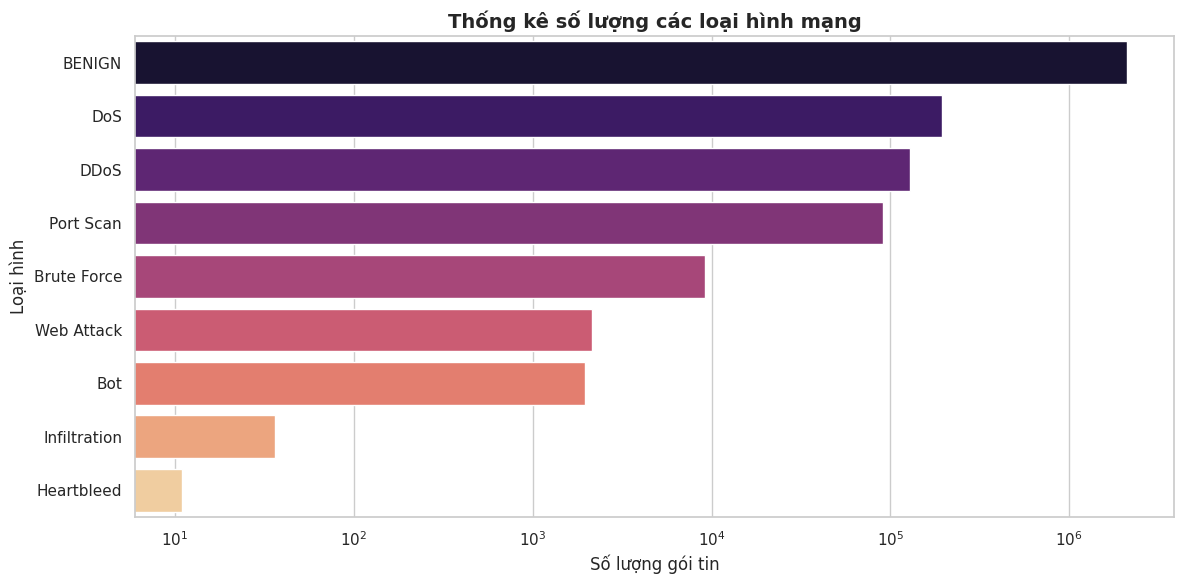

In [6]:
## Vẽ biểu đồ thống kê các loại tấn công
plt.figure(figsize=(12, 6))
attack_counts = y_text.value_counts()
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='magma')
plt.title('Thống kê số lượng các loại hình mạng', fontweight='bold', fontsize=14)
plt.xlabel('Số lượng gói tin', fontsize=12)
plt.ylabel('Loại hình', fontsize=12)
plt.xscale('log')
plt.tight_layout()
plt.show()

In [7]:
## Mã hóa nhãn và lưu bộ từ điển lại
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_text)
joblib.dump(encoder, '/content/drive/MyDrive/BTL_TSL_MR/MultiClass_LabelEncoder.pkl')
print(f"Đã lưu từ điển nhãn Đa lớp. Có tổng cộng {len(encoder.classes_)} loại hình.")

Đã lưu từ điển nhãn Đa lớp. Có tổng cộng 9 loại hình.


In [8]:
## Chia tập Train và Test
X_train_71, X_test_71, y_train, y_test = train_test_split(
    X_71, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [9]:
## Tính toán trọng số tự cân bằng
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [11]:
## Huấn luyện với 71 đặc trưng
start_time_71 = time.time()
## Cấu hình XGBoost
xgb_71 = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
xgb_71.fit(X_train_71, y_train, sample_weight=sample_weights)
train_time_71 = round(time.time() - start_time_71, 2)
y_pred_71 = xgb_71.predict(X_test_71)
acc_71 = accuracy_score(y_test, y_pred_71)
f1_71 = f1_score(y_test, y_pred_71, average='weighted')
precision_weighted_71 = precision_score(y_test, y_pred_71, average='weighted')
recall_weighted_71 = recall_score(y_test, y_pred_71, average='weighted')
print(f"Thời gian: {train_time_71}s | Acc: {acc_71*100:.2f}% | F1: {f1_71*100:.2f}% | Precision: {precision_weighted_71*100:.2f}% | Recall: {recall_weighted_71*100:.2f}%")
## Xuất file
joblib.dump(xgb_71, '/content/drive/MyDrive/BTL_TSL_MR/MultiClass_71Cols.pkl')

Thời gian: 277.69s | Acc: 99.90% | F1: 99.90% | Precision: 99.91% | Recall: 99.90%


['/content/drive/MyDrive/BTL_TSL_MR/MultiClass_71Cols.pkl']

In [13]:
df_optimal = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/optimal_data.csv')
print(f"Đã load xong dữ liệu với kích thước: {df_optimal.shape}")

Đã load xong dữ liệu với kích thước: (2522362, 21)


In [14]:
## In ra danh sách cột để kiểm tra
print("Danh sách các cột trong dữ liệu:")
print(df_optimal.columns.tolist())
## Xác định cột nhãn
target_col_optimal = 'Attack Type'
## Thay thế các ký tự đặc biệt trong cột nhãn
df[target_col] = df[target_col_optimal].replace(to_replace=r'[^a-zA-Z0-9\s\-_]', value='-', regex=True)

Danh sách các cột trong dữ liệu:
['Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Average Packet Size', 'Max Packet Length', 'Packet Length Variance', 'Bwd Packet Length Max', 'Avg Bwd Segment Size', 'Packet Length Mean', 'Destination Port', 'Packet Length Std', 'Total Length of Bwd Packets', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'act_data_pkt_fwd', 'Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Subflow Bwd Bytes', 'ACK Flag Count', 'Attack Type']


In [15]:
## Tách X (đặc trưng, gồm 21 cột) và y (nhãn)
X_21 = df.drop(columns=['Attack Type'])
y_text = df['Attack Type']

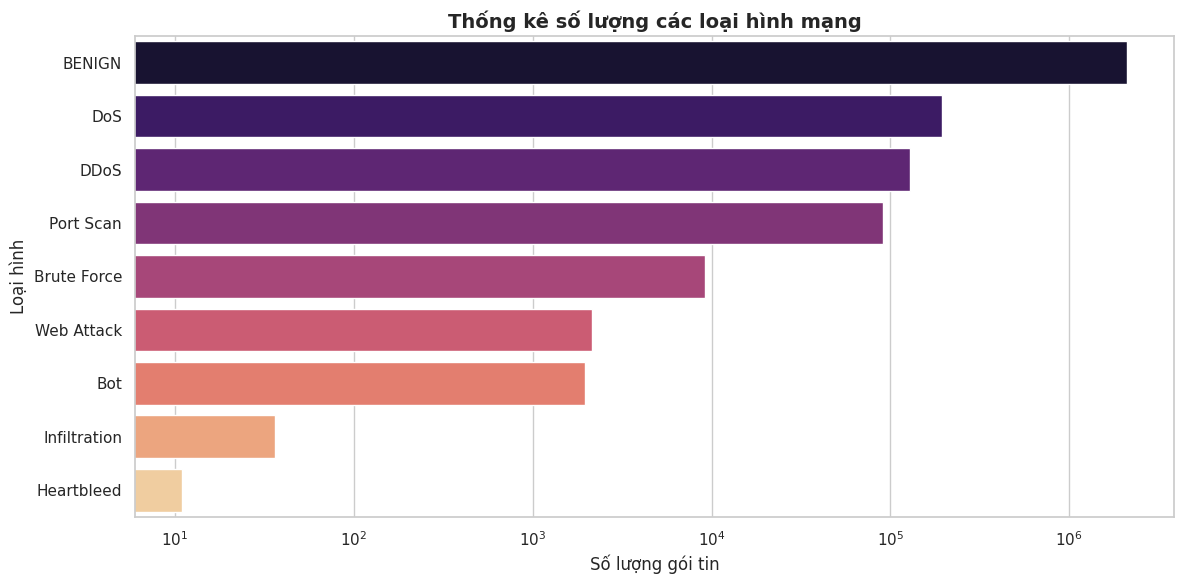

In [16]:
## Vẽ biểu đồ thống kê các loại tấn công
plt.figure(figsize=(12, 6))
attack_counts = y_text.value_counts()
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='magma')
plt.title('Thống kê số lượng các loại hình mạng', fontweight='bold', fontsize=14)
plt.xlabel('Số lượng gói tin', fontsize=12)
plt.ylabel('Loại hình', fontsize=12)
plt.xscale('log')
plt.tight_layout()
plt.show()

In [17]:
## Mã hóa nhãn và lưu bộ từ điển lại
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_text)
joblib.dump(encoder, '/content/drive/MyDrive/BTL_TSL_MR/MultiClass_LabelEncoder_21.pkl')
print(f"Đã lưu từ điển nhãn Đa lớp. Có tổng cộng {len(encoder.classes_)} loại hình.")

Đã lưu từ điển nhãn Đa lớp. Có tổng cộng 9 loại hình.


In [18]:
## Chia tập Train và Test
X_train_21, X_test_21, y_train, y_test = train_test_split(
    X_21, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [19]:
## Tính toán trọng số tự cân bằng
sample_weights_optimal = compute_sample_weight(class_weight='balanced', y=y_train)

In [20]:
## Huấn luyện với 21 đặc trưng
start_time_21 = time.time()
## Cấu hình XGBoost
xgb_21 = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
xgb_21.fit(X_train_21, y_train, sample_weight=sample_weights_optimal)
train_time_21 = round(time.time() - start_time_21, 2)
y_pred_21 = xgb_21.predict(X_test_21)
acc_21 = accuracy_score(y_test, y_pred_21)
f1_21 = f1_score(y_test, y_pred_21, average='weighted')
precision_weighted_21 = precision_score(y_test, y_pred_21, average='weighted')
recall_weighted_21 = recall_score(y_test, y_pred_21, average='weighted')
print(f"Thời gian: {train_time_21}s | Acc: {acc_21*100:.2f}% | F1: {f1_21*100:.2f}% | Precision: {precision_weighted_21*100:.2f}% | Recall: {recall_weighted_21*100:.2f}%")
## Xuất file
joblib.dump(xgb_21, '/content/drive/MyDrive/BTL_TSL_MR/MultiClass_21Cols.pkl')

Thời gian: 275.45s | Acc: 99.90% | F1: 99.90% | Precision: 99.91% | Recall: 99.90%


['/content/drive/MyDrive/BTL_TSL_MR/MultiClass_21Cols.pkl']

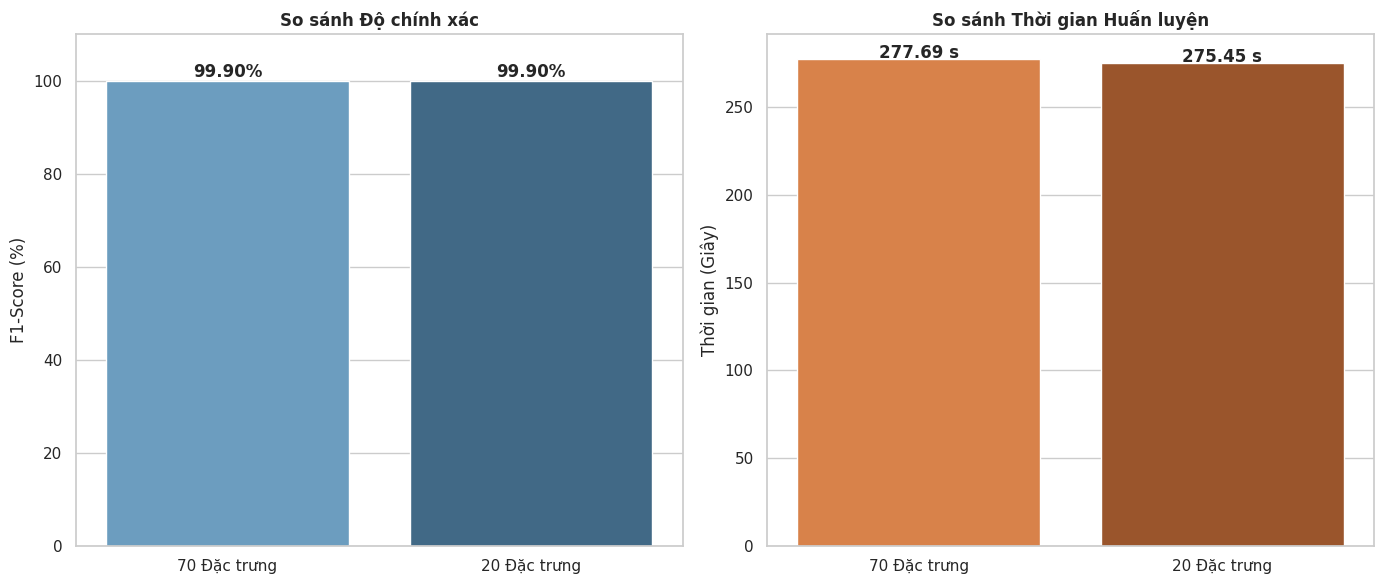

In [21]:
## Vẽ biểu đồ so sánh
models_comparison = ['70 Đặc trưng', '20 Đặc trưng']
f1_scores = [f1_71 * 100, f1_21 * 100]
train_times = [train_time_71, train_time_21]
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
## Biểu đồ F1-Score
sns.barplot(x=models_comparison, y=f1_scores, ax=ax[0], palette='Blues_d')
ax[0].set_title('So sánh Độ chính xác', fontweight='bold')
ax[0].set_ylabel('F1-Score (%)')
ax[0].set_ylim(0, 110)
for i, v in enumerate(f1_scores):
    ax[0].text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
## Biểu đồ Thời gian huấn luyện
sns.barplot(x=models_comparison, y=train_times, ax=ax[1], palette='Oranges_d')
ax[1].set_title('So sánh Thời gian Huấn luyện', fontweight='bold')
ax[1].set_ylabel('Thời gian (Giây)')
for i, v in enumerate(train_times):
    ax[1].text(i, v + 0.5, f"{v:.2f} s", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

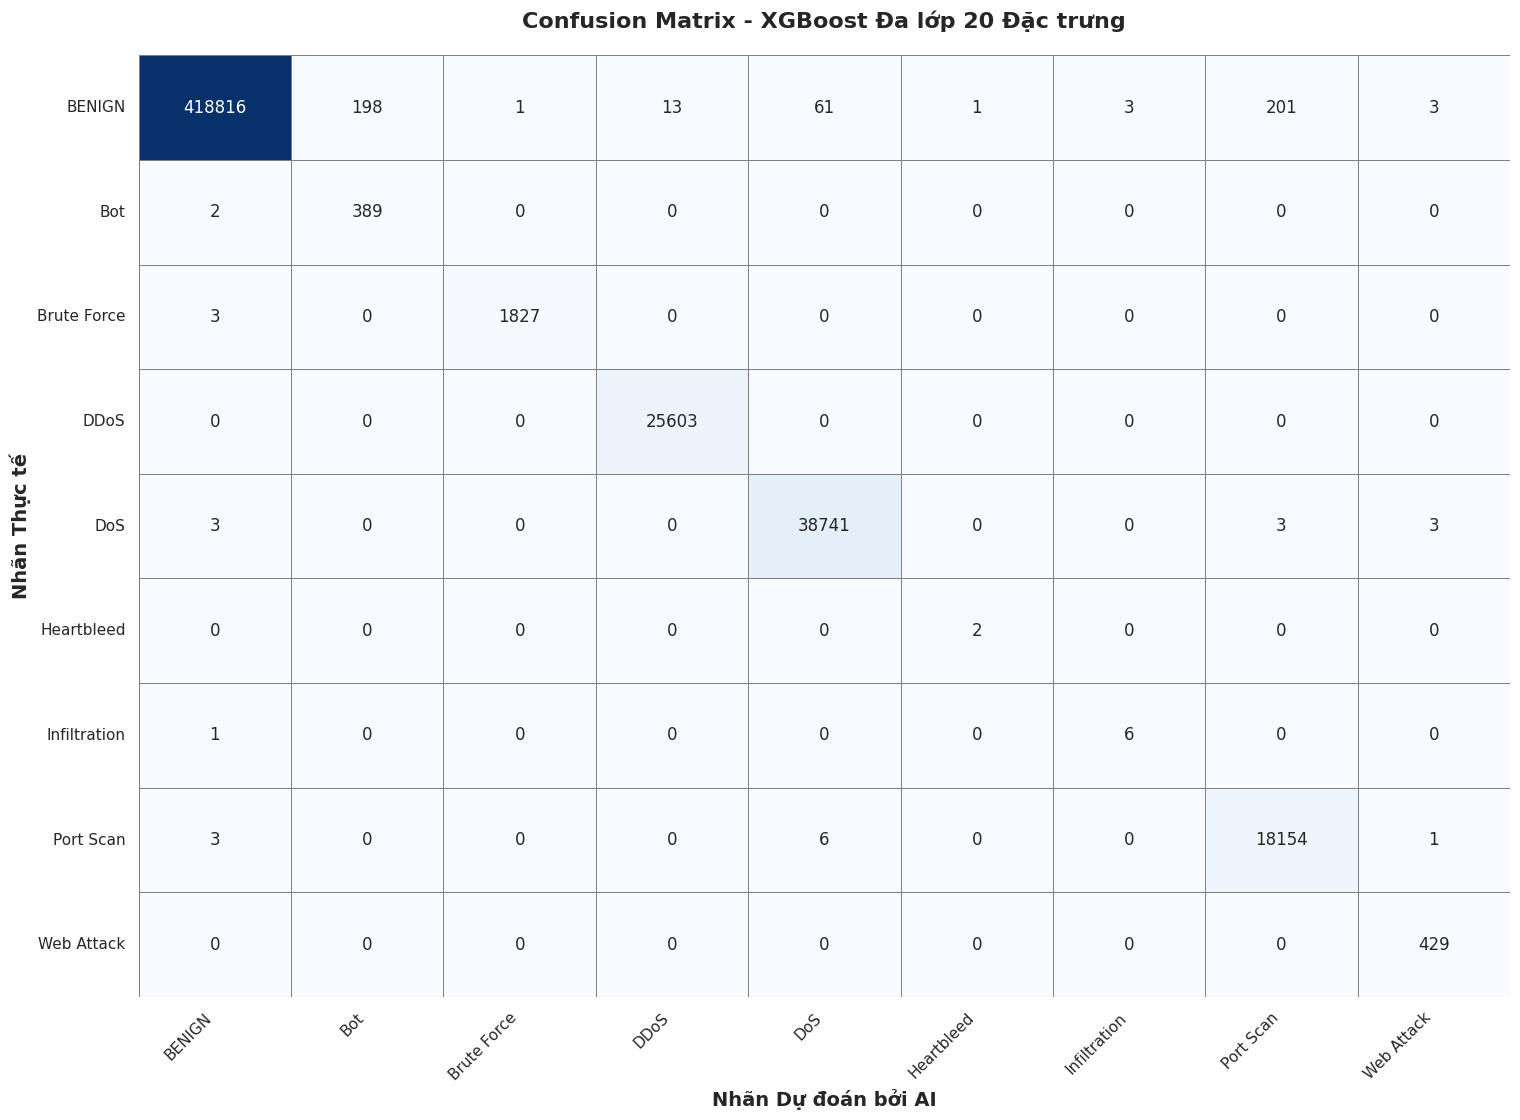

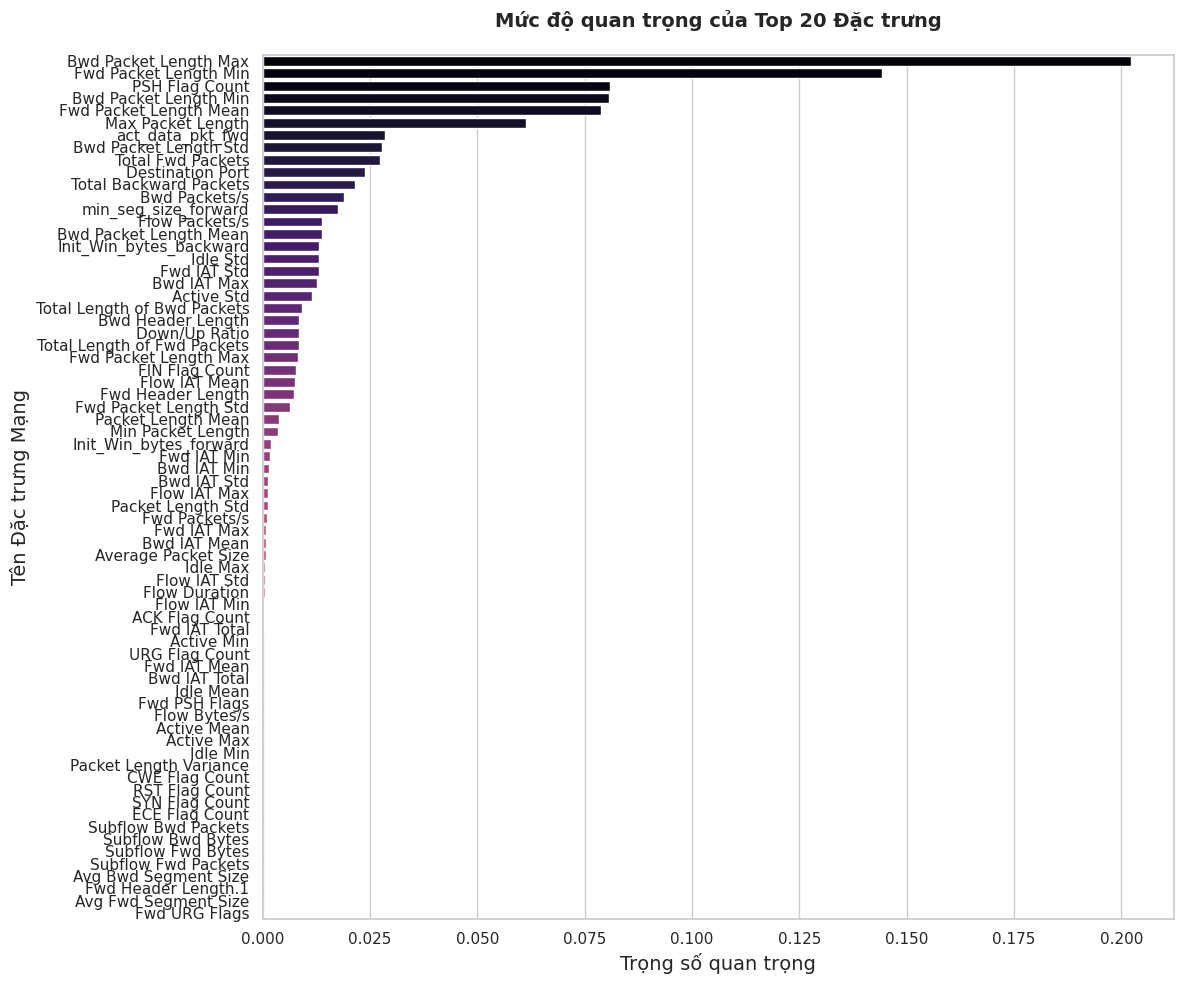

In [22]:
## Vẽ confusion matrix và độ quan trọng đặc trưng
## Vẽ confusion matrix
cm = confusion_matrix(y_test, y_pred_21)
plt.figure(figsize=(16, 12)) # Tăng kích thước chiều rộng
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            linewidths=.5, linecolor='gray')
plt.title('Confusion Matrix - XGBoost Đa lớp 20 Đặc trưng', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Nhãn Thực tế', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn Dự đoán bởi AI', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout(pad=3.0)
plt.show()
## Vẽ Mức độ đóng góp của Đặc trưng
importances = xgb_21.feature_importances_
indices = np.argsort(importances)[::-1]
## Lấy tên các đặc trưng từ X_train_21
feature_names = X_train_21.columns.tolist()
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]
plt.figure(figsize=(12, 10))
sns.barplot(x=sorted_importances, y=sorted_features, palette='magma')
plt.title('Mức độ quan trọng của Top 20 Đặc trưng', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Trọng số quan trọng', fontsize=14)
plt.ylabel('Tên Đặc trưng Mạng', fontsize=14)
plt.subplots_adjust(left=0.3)
plt.tight_layout()
plt.show()

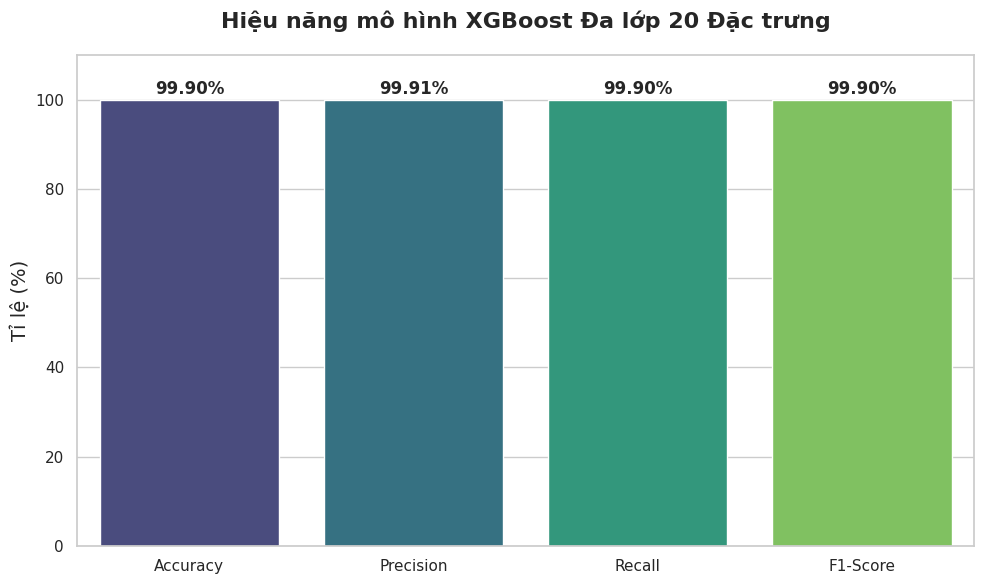

In [23]:
## Vẽ biểu đồ tổng hợp
## Tính toán 4 chỉ số quan trọng nhất
acc = accuracy_score(y_test, y_pred_21)
prec = precision_score(y_test, y_pred_21, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred_21, average='weighted')
f1 = f1_score(y_test, y_pred_21, average='weighted')
## Chuẩn bị dữ liệu vẽ biểu đồ
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_scores = [acc * 100, prec * 100, rec * 100, f1 * 100]
plt.figure(figsize=(10, 6))
## Vẽ biểu đồ cột với màu sắc gradient đẹp mắt
ax = sns.barplot(x=metrics_names, y=metrics_scores, palette='viridis')
plt.title('Hiệu năng mô hình XGBoost Đa lớp 20 Đặc trưng', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Tỉ lệ (%)', fontsize=14)
plt.ylim(0, 110) # Để lại khoảng trống phía trên cho đẹp
## Ghi chú phần trăm lên đầu mỗi cột
for i, v in enumerate(metrics_scores):
    ax.text(i, v + 1.5, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

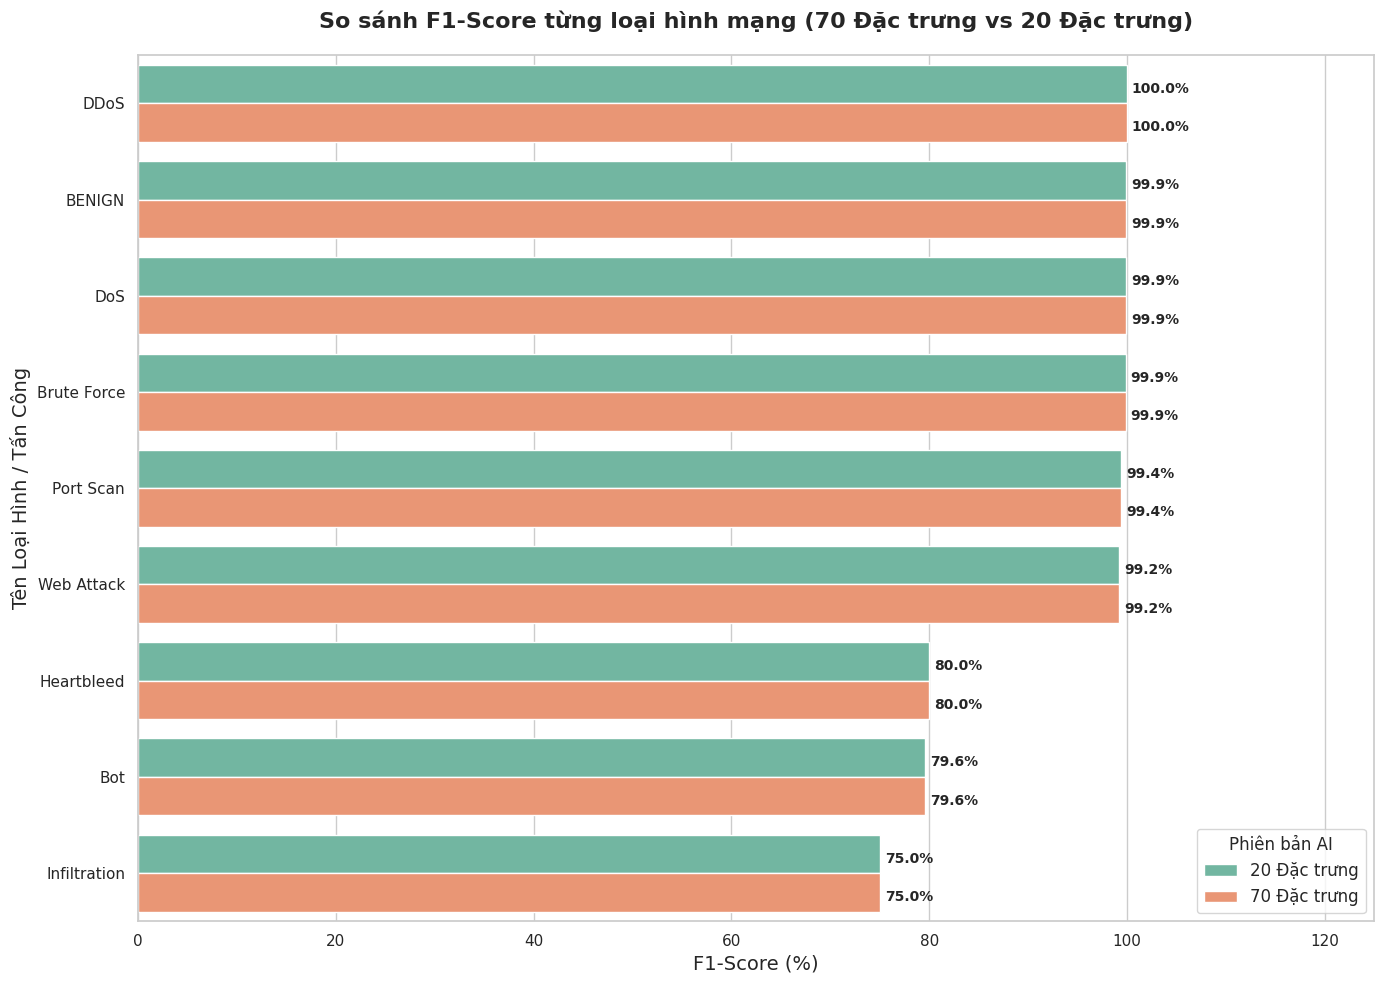

In [24]:
## Vẽ biểu đồ so sánh F1-score
## Rút xuất báo cáo của cả 2 mô hình
report_71 = classification_report(y_test, y_pred_71, target_names=encoder.classes_, output_dict=True)
report_21 = classification_report(y_test, y_pred_21, target_names=encoder.classes_, output_dict=True)

## Gom dữ liệu vào một danh sách để tạo bảng
data = []
for label in encoder.classes_:
    ## Lấy điểm của 71 cột
    data.append({
        'Loại hình': label,
        'F1-Score (%)': report_71[label]['f1-score'] * 100,
        'Mô hình': '70 Đặc trưng'
    })
    ## Lấy điểm của 21 cột
    data.append({
        'Loại hình': label,
        'F1-Score (%)': report_21[label]['f1-score'] * 100,
        'Mô hình': '20 Đặc trưng'
    })

## Tạo DataFrame
df_compare = pd.DataFrame(data)

## Sửa lỗi logic sắp xếp: Sử dụng đúng tên '20 Đặc trưng'
df_sort_order = df_compare[df_compare['Mô hình'] == '20 Đặc trưng'].sort_values(by='F1-Score (%)', ascending=False)['Loại hình'].tolist()
df_compare['Loại hình'] = pd.Categorical(df_compare['Loại hình'], categories=df_sort_order, ordered=True)
df_compare = df_compare.sort_values('Loại hình')

## Tiến hành vẽ Biểu đồ cột ghép
plt.figure(figsize=(14, 10))
ax = sns.barplot(x='F1-Score (%)', y='Loại hình', hue='Mô hình', data=df_compare, palette='Set2')

plt.title('So sánh F1-Score từng loại hình mạng (70 Đặc trưng vs 20 Đặc trưng)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('F1-Score (%)', fontsize=14)
plt.ylabel('Tên Loại Hình / Tấn Công', fontsize=14)
plt.xlim(0, 125)
plt.legend(title='Phiên bản AI', fontsize=12, title_fontsize=12, loc='lower right')

## Ghi chú số phần trăm lên đuôi mỗi cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.5, p.get_y() + p.get_height()/2. + 0.05,
                 f'{width:.1f}%', ha="left", va="center", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# 1. Tính toán số lượng và tỷ lệ % - Chuyển đổi nhãn số sang nhãn chữ
unique_ids, counts = np.unique(y_pred_21, return_counts=True)
unique_names = encoder.inverse_transform(unique_ids) # Chuyển số -> chữ

df_analysis = pd.DataFrame({'Loại': unique_names, 'Số lượng': counts})
df_analysis['Tỷ lệ %'] = (df_analysis['Số lượng'] / len(y_pred_21)) * 100
df_analysis = df_analysis.sort_values(by='Tỷ lệ %', ascending=False).reset_index(drop=True)

# 2. Hiển thị bảng kết quả
print("-" * 40)
print("BẢNG PHÂN TÍCH CHI TIẾT LƯU LƯỢNG MẠNG")
print("-" * 40)
display(df_analysis.style.format({'Tỷ lệ %': '{:.2f}%'}))

# 3. Logic dự đoán trạng thái hệ thống
benign_row = df_analysis[df_analysis['Loại'] == 'BENIGN']
benign_rate = benign_row['Tỷ lệ %'].values[0] if not benign_row.empty else 0

if benign_rate < 50:
    top_attack = df_analysis[df_analysis['Loại'] != 'BENIGN'].iloc[0]
    print(f"\n⚠️ CẢNH BÁO: Hệ thống đang bị tấn công trọng điểm: [{top_attack['Loại']}]")
    print(f"Kiểu tấn công này chiếm {top_attack['Tỷ lệ %']:.2f}% tổng lưu lượng.")
else:
    print("\n✅ TRẠNG THÁI: Lưu lượng sạch (BENIGN) chiếm đa số.")

----------------------------------------
BẢNG PHÂN TÍCH CHI TIẾT LƯU LƯỢNG MẠNG
----------------------------------------


,Loại,Số lượng,Tỷ lệ %
0,BENIGN,418828,83.02%
1,DoS,38808,7.69%
2,DDoS,25616,5.08%
3,Port Scan,18358,3.64%
4,Brute Force,1828,0.36%
5,Bot,587,0.12%
6,Web Attack,436,0.09%
7,Infiltration,9,0.00%
8,Heartbleed,3,0.00%



✅ TRẠNG THÁI: Lưu lượng sạch (BENIGN) chiếm đa số.


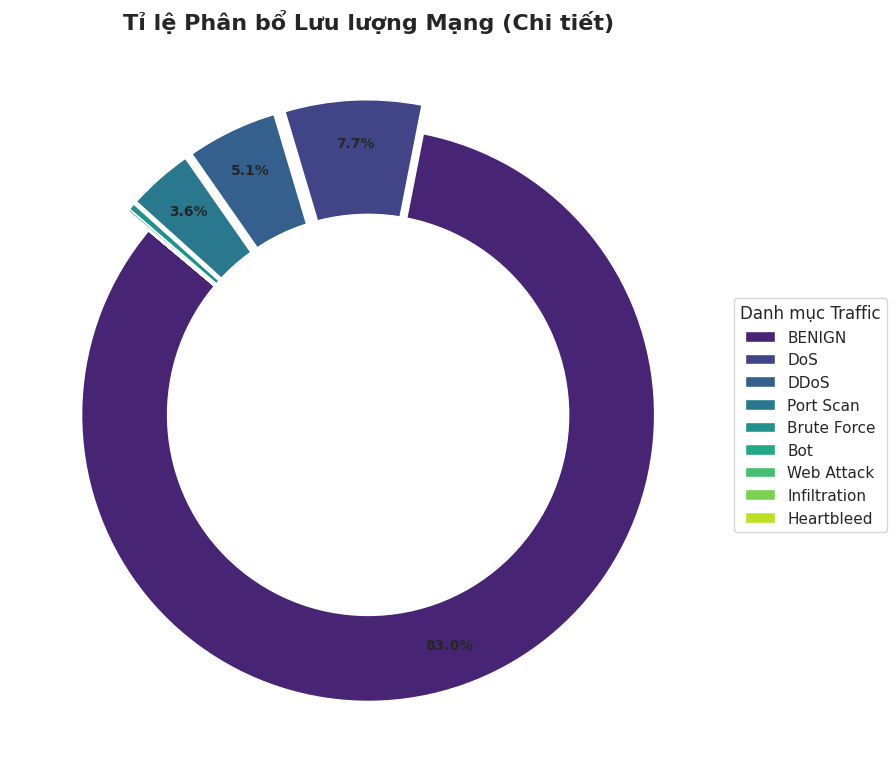

In [26]:
# Tối ưu biểu đồ tròn: Thêm chú thích và tránh trùng lặp số liệu
plt.figure(figsize=(12, 8))

# Chuẩn bị dữ liệu và màu sắc
data = df_analysis['Tỷ lệ %']
labels = df_analysis['Loại']
colors = sns.color_palette('viridis', len(df_analysis))

# Vẽ biểu đồ tròn với các tùy chỉnh để dễ nhìn hơn
wedges, texts, autotexts = plt.pie(
    data,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85, # Đẩy con số ra xa tâm một chút
    explode=[0.1 if x != 'BENIGN' else 0 for x in labels],
    textprops={'fontsize': 10, 'fontweight': 'bold'} # Chỉnh font cho số %
)

# Làm sạch các con số: Nếu tỉ lệ quá nhỏ (< 1%) thì không hiện số trực tiếp trên hình để tránh đè chữ
for i, a in enumerate(autotexts):
    if data[i] < 1.0:
        a.set_text("")

# Thêm chú thích (Legend) ở bên cạnh thay vì viết chữ trực tiếp lên hình
plt.legend(wedges, labels,
           title="Danh mục Traffic",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Tỉ lệ Phân bổ Lưu lượng Mạng (Chi tiết)', fontsize=16, fontweight='bold', pad=20)

# Vẽ vòng tròn trắng ở giữa để tạo hiệu dạng Donut (giúp biểu đồ trông hiện đại và dễ nhìn hơn)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()